# Quickstart

This example models steady-state groundwater flow on a 10×10 structured
(DIS) grid.  A constant-head (CHD) boundary drives flow from the
upper-left corner (head = 1 m) diagonally to the lower-right corner
(head = 0 m).

Quickstart example:
* define a `Simulation` and attach packages using the `parent=` API
* inspect package data through the `.data` accessor and xarray `.sel()`
* read binary head and budget output via `gwf.output`
* produce a filled-contour + quiver plot with matplotlib

### Imports

In [1]:
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from flopy.discretization.structuredgrid import StructuredGrid

In [3]:
from flopy4.mf6.gwf import Chd, Gwf, Ic, Npf, Oc
from flopy4.mf6.ims import Ims
from flopy4.mf6.simulation import Simulation
from flopy4.mf6.utils.time import Time

### Setup

In [4]:
try:
    QS_ROOT = Path(__file__).parent
except NameError:
    QS_ROOT = Path.cwd()

### Timing

One steady-state stress period of length 1.0 with a single time step.

In [5]:
name = "quickstart"
workspace = QS_ROOT / name
workspace.mkdir(exist_ok=True)
time = Time(perlen=[1.0], nstp=[1])

### Grid

A 1-layer, 10-row, 10-column DIS grid with uniform 1 m × 1 m cells.

In [6]:
grid = StructuredGrid(
    nlay=1,
    nrow=10,
    ncol=10,
    delr=1.0 * np.ones(10),
    delc=1.0 * np.ones(10),
    top=1.0 * np.ones((10, 10)),
    botm=0.0 * np.ones((1, 10, 10)),
)

### Packages

Packages are attached to their parent at construction time via `parent=`.
This differs from the constructor-kwargs style used in other examples.

`Ims` (iterative solver) is registered with the simulation via
`parent=sim`; `models=[gwf_name]` links it to the named flow model.

In [7]:
sim = Simulation(name=name, workspace=workspace, tdis=time)
gwf_name = "mymodel"
ims = Ims(parent=sim, models=[gwf_name])  # registered with sim; references the model by name
gwf = Gwf(parent=sim, name=gwf_name, save_flows=True, dis=grid)

In [8]:
# Node-property flow: isotropic conductivity; saves specific-discharge for quiver plots.
npf = Npf(parent=gwf, print_flows=True, save_flows=True, save_specific_discharge=True)

In [9]:
# Constant-head boundary: pin two corner cells to create a diagonal head gradient.
chd = Chd(
    parent=gwf,
    head={0: {(0, 0, 0): 1.0, (0, 9, 9): 0.0}},
)

In [10]:
# Initial conditions: uniform starting head of 1.0 m across the grid.
ic = Ic(parent=gwf, strt=1.0)

In [11]:
# Output control: write heads and budget to binary files at every time step.
oc = Oc(
    parent=gwf,
    budget_file=f"{gwf.name}.bud",
    head_file=f"{gwf.name}.hds",
    save_head={0: "all"},
    save_budget={0: "all"},
)

### Write and run

In [12]:
sim.write()
sim.run(verbose=True)

running: mf6
stdout:
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                  VERSION 6.8.0.dev0 (preliminary) 02/06/2026
                               ***DEVELOP MODE***

        MODFLOW 6 compiled Feb 25 2026 15:19:23 with GCC version 13.3.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the authorized or unauthorized 
use of the software.


 MODFLOW runs in SEQUENTIAL mode

 Run start date and time 

### Verify package data

Each package exposes its input through `.data`, an xarray Dataset.
Stress-period integer keys are coordinates; `.sel(kper=0)` selects
period 0.  Inactive cell slots contain `3e30` (MODFLOW's no-data value).

In [13]:
assert chd.data["head"][0, 0] == 1.0
assert chd.data.head.sel(kper=0)[99] == 0.0
assert np.allclose(chd.data.head[:, 1:99], np.full(98, 3e30))

In [14]:
assert gwf.dis.data.botm.sel(lay=0, col=0, row=0) == 0.0

In [15]:
assert oc.data["save_head"][0] == "all"
assert oc.data.save_head.sel(kper=0) == "all"

### Read results

`gwf.output.head` returns an `xr.DataArray` with named dimensions
(layer, y, x, time).  `.squeeze()` drops length-1 dimensions so we
get a 2-D (y, x) array ready for plotting.
`gwf.output.budget` returns an `xr.Dataset` keyed by budget term
(e.g. `npf-qx`, `npf-qy` for the specific-discharge components).

In [16]:
# get head and budget results
budget = gwf.output.budget.squeeze()
head = gwf.output.head.squeeze()

/home/mjreno/.clone/dev/pyphoenix-project/flopy4/mf6/utils/cbc_reader.py:138: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.merge([cbc])
/home/mjreno/.clone/dev/pyphoenix-project/flopy4/mf6/utils/cbc_reader.py:138: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.merge([cbc])


### Plot

Overlay filled head contours with specific-discharge quiver vectors.
The quiver `u`/`v` components come from the NPF budget terms saved above.

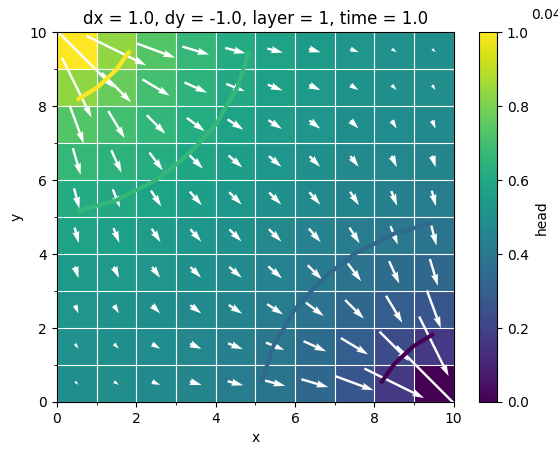

In [17]:
# make plot
fig, ax = plt.subplots()
ax.tick_params()
ax.set_xticks(np.arange(0, 11, 2), minor=False)
ax.set_xticks(np.arange(1, 10, 2), minor=True)
ax.set_yticks(np.arange(0, 11, 2), minor=False)
ax.set_yticks(np.arange(1, 10, 2), minor=True)
ax.grid(which="both", color="white")
head.plot.imshow(ax=ax)
head.plot.contour(ax=ax, levels=[0.2, 0.4, 0.6, 0.8], linewidths=3.0)
budget.plot.quiver(x="x", y="y", u="npf-qx", v="npf-qy", ax=ax, color="white")
fig.savefig(workspace / "quickstart.png")